In [1]:
import numpy as np                    
import matplotlib.pyplot as plt        
from sklearn.linear_model import Ridge

In [2]:
N = 50 #number of virtual nodes
theta = 10**-10 #interval length 
p = 1.11 #normalised injection current
eta = 0.08 #input strength 
alpha = 3 #linewidth enhancemenet factor
phi = 0.0 #phase shift
kappa = 10**8
dt = 10**-12


T = N*theta # mask period
tau = 1.01*T # feedback delay time, why are these different
Nd = int(round(tau / dt))  
tap_stride = int(round(theta / dt)) 

In [3]:
def generate_mask(N, rng=None):
    rng = np.random.default_rng(rng)
    return rng.random(N)   # default values between 0 and 1 range.



mask = generate_mask(N, rng=42)

In [4]:
x = 0.0
buffer = np.zeros(Nd) #it stores past Nd states (keeps track of)
buffer_idx = 0 # index pointer for buffer

In [5]:
def ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta):
  
  
    I = abs(E)**2  

    dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)

    dndt = p + eta * v_slot - (1.0 + I) * n

    return dEdt, dndt


In [6]:
def rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta):
    
   # One RK4 step. v should be v over tap_stride duration. 
 
    # k1
    k1_E, k1_n = ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k2
    E2 = E + 0.5 * dt * k1_E
    n2 = n + 0.5 * dt * k1_n
    k2_E, k2_n = ODEs(E2, n2, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k3
    E3 = E + 0.5 * dt * k2_E
    n3 = n + 0.5 * dt * k2_n
    k3_E, k3_n = ODEs(E3, n3, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k4
    E4 = E + dt * k3_E
    n4 = n + dt * k3_n
    k4_E, k4_n = ODEs(E4, n4, E_delay, v_slot, alpha, kappa, phi, p, eta)


    E_next = E + (dt/6.0) * (k1_E + 2*k2_E + 2*k3_E + k4_E)
    n_next = n + (dt/6.0) * (k1_n + 2*k2_n + 2*k3_n + k4_n)

    return E_next, n_next

### Attempt 1: single node TDM for ELM

in this attempt we kept N fixed

this contrasts attempt 2 below, in which:  we swept for N, alpha values for ridge regression(not to be confused with the alpha that is the linewidth enhacement factor, part of the kobayashi resevoir.., see second section of this notebook),as well as added parameter g

In [7]:
#chill task to verify encoding and decoding pipeline
L = 2000       # size of input data.
rng = np.random.default_rng(0)
x = rng.uniform(-1, 1, size=L)    # input
y = np.sin(2 * np.pi * x)         # target function 

In [8]:
# standardised input like RC papers
x_norm = (x - np.mean(x)) / np.std(x)

In [9]:
V = np.outer(x_norm, mask)   # will be the Vl,n matrix. matrix of masked input values

In [10]:


L, N = V.shape
R = np.zeros((L, N))

#below for the sequentiqal feeding of masked input into the resevoir
#shall be replaced later with actual ODEs

for l in range(L):
    for n in range(N):          
        v_ln = V[l, n]          
        R[l, n] = np.tanh(v_ln) 
        
        
#R = np.tanh(V) #static computation, ie no need for loop which makes it run faster but this could be looked at later on.

ELM–TDM test
MSE   = 5.9773e-04
NRMSE = 0.0348


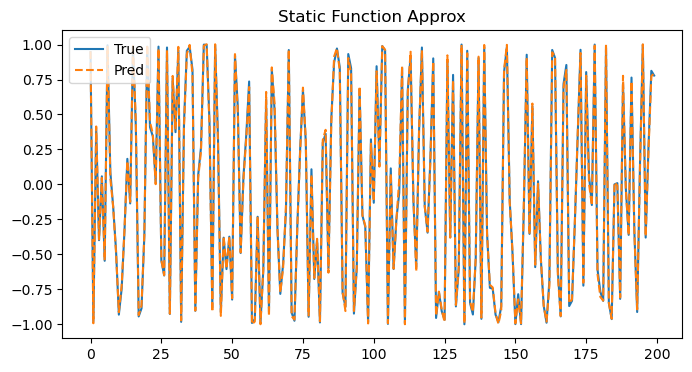

In [11]:
# Train/test 
split = int(0.8 * L)
R_train, R_test = R[:split], R[split:]
y_train, y_test = y[:split], y[split:]

#  decoding 
ridge = Ridge(alpha=1e-4, fit_intercept=False)
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

# MSE
mse = np.mean((y_test - y_pred)**2)
nrmse = np.sqrt(mse / np.var(y_test))

print("ELM–TDM test")
print(f"MSE   = {mse:.4e}")
print(f"NRMSE = {nrmse:.4f}")


# plot for verification
plt.figure(figsize=(8,4))
plt.plot(y_test[:200], label="True")
plt.plot(y_pred[:200], label="Pred", linestyle="--")
plt.title("Static Function Approx")
plt.legend()
plt.show()


### attempt 2: improving attempt 1 by lowering loss value

the above test gave us an NMRSE of 0.0348, which is good but not great. Before implementing optical resevoir dynamics, getting a lower optimum value is probably a good idea. We can do this in a few fronts:

- a)adding a gain to control where tanh operates. if we have tanh(x), if x is too small coversion is almost linear so not enogh richness. If x is too large then tanh saturates at +-1 so info is lost(look up tanh function graph). Having a gain term such as tanh(gx) and sweeping g parameters we can see what gives lowest test NMRSE
- b)Increasing number of virtual Nodes, rn only using 50, but probably more = better.
- c)tuning ridge parameter, right now probably a little small. 

In [12]:
#def generate_mask_v2(N, rng=None):
#    rng = np.random.default_rng(rng)
 #   return rng.uniform(-1, 1, size=N)   

#mask = generate_mask_v2(N, rng=42)

In [17]:
N_list     = [50, 100, 200]
g_list     = [0.3, 1.0, 3.0]
alpha_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

best_combination = None # (N, g, alpha_star)
best_nrmse = 1e9                

for N in N_list:
    
    mask = generate_mask(N, rng=42)
    V = np.outer(x_norm, mask)
    L, _ = V.shape
    split = int(0.8 * L)

    for g in g_list:
        
        R = np.zeros((L, N))
        for l in range(L):
            for n in range(N):
                v_ln = V[l, n]
                R[l, n] = np.tanh(g * v_ln)

     
        R_train, R_test = R[:split], R[split:]
        y_train, y_test = y[:split], y[split:]

        # store train/test curves vs alpha for THIS (N, g)
        train_nrmse_list = []
        test_nrmse_list  = []

        for alpha in alpha_list:
            ridge = Ridge(alpha=alpha, fit_intercept=False)
            ridge.fit(R_train, y_train)

        
            y_pred_train = ridge.predict(R_train)
            y_pred_test  = ridge.predict(R_test)

            
            mse_train = np.mean((y_train - y_pred_train)**2)
            train_nrmse = np.sqrt(mse_train / np.var(y_train))

            mse_test = np.mean((y_test - y_pred_test)**2)
            test_nrmse = np.sqrt(mse_test / np.var(y_test))

            train_nrmse_list.append(train_nrmse)
            test_nrmse_list.append(test_nrmse)

            print(f"N={N:3d}, g={g:.1f}, alpha={alpha:.0e}, "
                  f"train NRMSE={train_nrmse:.5f}, test NRMSE={test_nrmse:.5f}")

        # bias-variance crossover code:
        train_nrmse_arr = np.array(train_nrmse_list)
        test_nrmse_arr  = np.array(test_nrmse_list)

        # array of differences between train and test NRMSE 
        #each alpha, for  this particular N, g combination
        gap = np.abs(train_nrmse_arr - test_nrmse_arr)

        # index of alpha where train and test are closest 
        idx_star = np.argmin(gap)
        alpha_star = alpha_list[idx_star]
        test_nrmse_star = test_nrmse_arr[idx_star]
        train_nrmse_star = train_nrmse_arr[idx_star]

        print(f"--> For N={N}, g={g}, "
              f"chosen alpha={alpha_star:.0e} (closest train/test: "
              f"{train_nrmse_star:.5f} / {test_nrmse_star:.5f})")

       
        if test_nrmse_star < best_nrmse:
            best_nrmse = test_nrmse_star
            best_combination = (N, g, alpha_star)

print("\nBest combination (using train/test intersection per (N, g)):")
print(f"N={best_combination[0]}, g={best_combination[1]}, "
      f"alpha={best_combination[2]:.0e}, best test NRMSE={best_nrmse:.5f}")

N= 50, g=0.3, alpha=1e-06, train NRMSE=0.32371, test NRMSE=0.32224
N= 50, g=0.3, alpha=1e-05, train NRMSE=0.64782, test NRMSE=0.64227
N= 50, g=0.3, alpha=1e-04, train NRMSE=0.81787, test NRMSE=0.81005
N= 50, g=0.3, alpha=1e-03, train NRMSE=0.84136, test NRMSE=0.83331
N= 50, g=0.3, alpha=1e-02, train NRMSE=0.84511, test NRMSE=0.83781
--> For N=50, g=0.3, chosen alpha=1e-06 (closest train/test: 0.32371 / 0.32224)
N= 50, g=1.0, alpha=1e-06, train NRMSE=0.02405, test NRMSE=0.02361
N= 50, g=1.0, alpha=1e-05, train NRMSE=0.03003, test NRMSE=0.02946
N= 50, g=1.0, alpha=1e-04, train NRMSE=0.03539, test NRMSE=0.03476
N= 50, g=1.0, alpha=1e-03, train NRMSE=0.05156, test NRMSE=0.05128
N= 50, g=1.0, alpha=1e-02, train NRMSE=0.10973, test NRMSE=0.11016
--> For N=50, g=1.0, chosen alpha=1e-03 (closest train/test: 0.05156 / 0.05128)
N= 50, g=3.0, alpha=1e-06, train NRMSE=0.01478, test NRMSE=0.01506
N= 50, g=3.0, alpha=1e-05, train NRMSE=0.01764, test NRMSE=0.01763
N= 50, g=3.0, alpha=1e-04, train NRM

In [15]:
N_list     = [50, 100, 200]
g_list     = [0.3, 1.0, 3.0]
alpha_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

best_combination = None
best_nrmse = 1e9

for N in N_list:
    
    mask = generate_mask(N, rng=42)  
    V = np.outer(x_norm, mask)
    L, _ = V.shape
    split = int(0.8 * L)
    
    for g in g_list:
        
        R = np.zeros((L, N))
        for l in range(L):
            for n in range(N):
                v_ln = V[l, n]
                R[l,n] = np.tanh(g * v_ln)

        R_train, R_test = R[:split], R[split:]
        y_train, y_test = y[:split], y[split:]

        for alpha in alpha_list:
            ridge = Ridge(alpha=alpha, fit_intercept=False)
            ridge.fit(R_train, y_train)
            y_pred = ridge.predict(R_test)

            mse = np.mean((y_test - y_pred)**2)
            nrmse = np.sqrt(mse / np.var(y_test))

            if nrmse < best_nrmse:
                best_nrmse = nrmse
                best_combination = (N, g, alpha)

            print(f"N={N:3d}, g={g:.1f}, alpha={alpha:.0e}, NRMSE={nrmse:.5f}")

print("\nBest combination:")
print(f"N={best_combination[0]}, g={best_combination[1]}, alpha={best_combination[2]:.0e}, best NRMSE={best_nrmse:.5f}")

N= 50, g=0.3, alpha=1e-06, NRMSE=0.32224
N= 50, g=0.3, alpha=1e-05, NRMSE=0.64227
N= 50, g=0.3, alpha=1e-04, NRMSE=0.81005
N= 50, g=0.3, alpha=1e-03, NRMSE=0.83331
N= 50, g=0.3, alpha=1e-02, NRMSE=0.83781
N= 50, g=1.0, alpha=1e-06, NRMSE=0.02361
N= 50, g=1.0, alpha=1e-05, NRMSE=0.02946
N= 50, g=1.0, alpha=1e-04, NRMSE=0.03476
N= 50, g=1.0, alpha=1e-03, NRMSE=0.05128
N= 50, g=1.0, alpha=1e-02, NRMSE=0.11016
N= 50, g=3.0, alpha=1e-06, NRMSE=0.01506
N= 50, g=3.0, alpha=1e-05, NRMSE=0.01763
N= 50, g=3.0, alpha=1e-04, NRMSE=0.01918
N= 50, g=3.0, alpha=1e-03, NRMSE=0.02716
N= 50, g=3.0, alpha=1e-02, NRMSE=0.07610
N=100, g=0.3, alpha=1e-06, NRMSE=0.29569
N=100, g=0.3, alpha=1e-05, NRMSE=0.56612
N=100, g=0.3, alpha=1e-04, NRMSE=0.79445
N=100, g=0.3, alpha=1e-03, NRMSE=0.83186
N=100, g=0.3, alpha=1e-02, NRMSE=0.83681
N=100, g=1.0, alpha=1e-06, NRMSE=0.02064
N=100, g=1.0, alpha=1e-05, NRMSE=0.02839
N=100, g=1.0, alpha=1e-04, NRMSE=0.03245
N=100, g=1.0, alpha=1e-03, NRMSE=0.05163
N=100, g=1.0, al